# Checkpoint 2 — NAS Multiobjetivo com NSGA-II
**INF0415 · Heurísticas e Modelagem Multiobjetivo · UFG 2026/2**

Equipe: Raphael Alves, Wagner Victor, Victor Gabriel, Igor Dias, Lucas Fabricio

---

Este notebook implementa a busca evolutiva multiobjetivo de arquiteturas convolucionais compactas (NAS leve) via **NSGA-II** (pymoo), atendendo aos requisitos do Checkpoint 2:
- Versão multiobjetivo (NSGA-II)
- Comparação com versão single-objective (SA do Checkpoint 1)
- Baseline: busca aleatória + LeNet-5
- Fronteira de Pareto inicial com discussão de trade-offs

**Três objetivos a minimizar:**
- `f1 = 1 − acurácia` no conjunto de validação
- `f2 = nº de parâmetros treináveis` (proxy de memória)
- `f3 = FLOPs` de inferência (proxy de latência, independente de hardware)

## 0. Instalação de dependências

In [1]:
# Executar apenas uma vez no ambiente
# !pip install pymoo thop codecarbon torchinfo matplotlib seaborn scipy

## 1. Imports e configuração global (R6 — reprodutibilidade)

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.operators.repair.rounding import RoundingRepair
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.visualization.scatter import Scatter
from pymoo.indicators.hv import HV

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings, time, json, os, copy
warnings.filterwarnings('ignore')

# ── Reprodutibilidade (R6) ─────────────────────────────────────────────────
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
torch.cuda.manual_seed_all(GLOBAL_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
  GPU: NVIDIA GeForce RTX 4090
  VRAM: 25.2 GB


## 2. Espaço de busca — Genótipo (R1 — formulação matemática)

In [3]:
"""
Codificação do genótipo como vetor inteiro de comprimento fixo 14:

 idx | gene          | domínio (índices) | valores reais
 ----+---------------+-------------------+-----------------
  0  | L             | {0,1,2}           | {2,3,4} blocos
  1  | f1 (filtros)  | {0,1,2,3}         | {8,16,32,64}
  2  | k1 (kernel)   | {0,1,2}           | {3,5,7}
  3  | p1 (pool)     | {0,1}             | {False,True}
  4  | a1 (ativação) | {0,1}             | {ReLU,LeakyReLU}
  5  | f2            | {0,1,2,3}         | {8,16,32,64}
  6  | k2            | {0,1,2}           | {3,5,7}
  7  | p2            | {0,1}             | {False,True}
  8  | a2            | {0,1}             | {ReLU,LeakyReLU}
  9  | f3/f4 (extra) | {0,1,2,3}         | {8,16,32,64}  (blocos 3 e 4 usam mesmo valor quando L<4)
 10  | k3/k4         | {0,1,2}           | {3,5,7}
 11  | p3/p4         | {0,1}             | {False,True}
 12  | d (dense)     | {0,1,2}           | {32,64,128}
 13  | eta (lr idx)  | {0,1,2}           | {1e-2,1e-3,1e-4}

dropout é fixado em 0.25 para simplificar (pode ser adicionado como gene extra)
"""

# Tabelas de decodificação
L_VALS       = [2, 3, 4]
FILTER_VALS  = [8, 16, 32, 64]
KERNEL_VALS  = [3, 5, 7]
POOL_VALS    = [False, True]
ACT_VALS     = ['relu', 'leaky']
DENSE_VALS   = [32, 64, 128]
LR_VALS      = [1e-2, 1e-3, 1e-4]
DROPOUT_FIXED = 0.25

# Limites inferiores e superiores para pymoo (inteiros)
# Gene:  L   f1  k1  p1  a1  f2  k2  p2  a2  f3  k3  p3  d   lr
XL = np.array([0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0], dtype=int)
XU = np.array([2,  3,  2,  1,  1,  3,  2,  1,  1,  3,  2,  1,  2,  2], dtype=int)

N_GENES = len(XL)


def decode_genotype(x):
    """Converte vetor inteiro → dicionário de hiperparâmetros arquiteturais."""
    x = x.astype(int)
    n_blocks = L_VALS[x[0]]
    blocks = []
    # genes por bloco: 4 genes × até 3 blocos, mas encodamos só 3 slots (idx 1..11)
    # Bloco 1: genes 1-4; Bloco 2: genes 5-8; Bloco 3+: genes 9-11 (k e pool, sem gene a)
    block_genes = [
        (1, 2, 3, 4),   # bloco 1: f, k, p, a
        (5, 6, 7, 8),   # bloco 2: f, k, p, a
        (9, 10, 11, 4), # bloco 3: f, k, p, a (reutiliza a1 como ativação padrão)
        (9, 10, 11, 8), # bloco 4: f, k, p, a (reutiliza a2)
    ]
    for i in range(n_blocks):
        fi, ki, pi, ai = block_genes[i]
        blocks.append({
            'filters': FILTER_VALS[x[fi]],
            'kernel':  KERNEL_VALS[x[ki]],
            'pool':    POOL_VALS[x[pi]],
            'act':     ACT_VALS[x[ai]],
        })
    return {
        'n_blocks': n_blocks,
        'blocks': blocks,
        'dense_units': DENSE_VALS[x[12]],
        'dropout': DROPOUT_FIXED,
        'lr': LR_VALS[x[13]],
    }


def genotype_str(x):
    """Representação compacta em string para logging."""
    d = decode_genotype(x)
    blocks_str = '-'.join(
        f"{b['filters']}x{b['kernel']}{'p' if b['pool'] else ''}{b['act'][0]}"
        for b in d['blocks']
    )
    return f"{d['n_blocks']}blk [{blocks_str}] d{d['dense_units']} lr{d['lr']:.0e}"


# Teste rápido
test_x = np.array([1, 2, 0, 1, 0, 3, 1, 0, 1, 1, 2, 1, 1, 1])
print("Genótipo de teste:", genotype_str(test_x))
print(json.dumps(decode_genotype(test_x), indent=2))

Genótipo de teste: 3blk [32x3pr-64x5l-16x7pr] d64 lr1e-03
{
  "n_blocks": 3,
  "blocks": [
    {
      "filters": 32,
      "kernel": 3,
      "pool": true,
      "act": "relu"
    },
    {
      "filters": 64,
      "kernel": 5,
      "pool": false,
      "act": "leaky"
    },
    {
      "filters": 16,
      "kernel": 7,
      "pool": true,
      "act": "relu"
    }
  ],
  "dense_units": 64,
  "dropout": 0.25,
  "lr": 0.001
}


## 3. Construção da CNN a partir do genótipo

In [9]:
class NASConvNet(nn.Module):
    """
    CNN parametrizável construída a partir de um dicionário de hiperparâmetros.
    Entrada esperada: (B, 1, 28, 28) — Fashion-MNIST / MNIST.
    Saída: logits (B, 10).
    """
    def __init__(self, config: dict):
        super().__init__()
        layers = []
        in_ch = 1
        spatial = 28  # tamanho espacial inicial

        for blk in config['blocks']:
            k = blk['kernel']
            pad = k // 2  # padding 'same'
            layers.append(nn.Conv2d(in_ch, blk['filters'], kernel_size=k, padding=pad))
            layers.append(nn.BatchNorm2d(blk['filters']))
            if blk['act'] == 'relu':
                layers.append(nn.ReLU(inplace=True))
            else:
                layers.append(nn.LeakyReLU(0.1, inplace=True))
            if blk['pool'] and spatial >= 2:
                layers.append(nn.MaxPool2d(2))
                spatial //= 2
            in_ch = blk['filters']

        layers.append(nn.AdaptiveAvgPool2d(1))  # garante saída 1×1 independente do spatial
        self.features = nn.Sequential(*layers)
        flat_dim = in_ch  # após AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, config['dense_units']),
            nn.ReLU(inplace=True),
            nn.Dropout(config['dropout']),
            nn.Linear(config['dense_units'], 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def count_flops(model, input_size=(1, 1, 28, 28)):
    """
    Conta FLOPs usando uma CÓPIA do modelo em CPU.
    O modelo original nunca é movido — evita device mismatch.
    """
    model_cpu = copy.deepcopy(model).cpu().eval()
    try:
        from torchinfo import summary
        s = summary(model_cpu, input_size=input_size, verbose=0, device='cpu')
        return float(s.total_mult_adds) * 2
    except Exception:
        try:
            from thop import profile
            dummy = torch.zeros(*input_size)
            macs, _ = profile(model_cpu, inputs=(dummy,), verbose=False)
            return float(macs) * 2
        except Exception:
            return 0.0


# ── Teste de construção ──────────────────────────────────────────────────────
cfg = decode_genotype(test_x)
net = NASConvNet(cfg)
print(f"Parâmetros: {count_params(net):,}")
print(f"FLOPs est.: {count_flops(net)/1e6:.2f} MFLOPs")
dummy = torch.zeros(2, 1, 28, 28)
out = net(dummy)
print(f"Shape saída: {out.shape}  ✓")

Parâmetros: 103,738
FLOPs est.: 40.28 MFLOPs
Shape saída: torch.Size([2, 10])  ✓


## 4. Dataset Fashion-MNIST e MNIST (sanidade)

In [10]:
BATCH_SIZE = 128
NUM_WORKERS = 4  # ajustar conforme a máquina

_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),  # média/std do Fashion-MNIST
])

# ── Fashion-MNIST (dataset principal) ────────────────────────────────────────
fmnist_train_full = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=_transform
)
fmnist_test = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=_transform
)

# Split treino / validação: 50k / 10k (índices fixos para reprodutibilidade)
rng = np.random.default_rng(GLOBAL_SEED)
idx = rng.permutation(len(fmnist_train_full))
train_idx, val_idx = idx[:50000], idx[50000:]

fmnist_train = Subset(fmnist_train_full, train_idx)
fmnist_val   = Subset(fmnist_train_full, val_idx)

train_loader = DataLoader(fmnist_train, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(fmnist_val,   batch_size=256, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(fmnist_test,  batch_size=256, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# ── MNIST (sanidade) ─────────────────────────────────────────────────────────
_transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
mnist_test = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=_transform_mnist
)
mnist_test_loader = DataLoader(mnist_test, batch_size=256, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=True)

print(f"Fashion-MNIST  treino={len(fmnist_train):,} | val={len(fmnist_val):,} | teste={len(fmnist_test):,}")
print(f"MNIST          teste={len(mnist_test):,} (apenas sanidade)")

Fashion-MNIST  treino=50,000 | val=10,000 | teste=10,000
MNIST          teste=10,000 (apenas sanidade)


## 5. Função de avaliação (treina + avalia um indivíduo)

In [11]:
# ── Orçamento de treinamento fixo (R1 — comparação justa) ───────────────────
TRAIN_EPOCHS = 5   # durante busca; aumentar para avaliação final da fronteira
MAX_PARAMS   = 500_000  # restrição flexível: arquiteturas acima são penalizadas


def train_and_eval(config: dict, seed: int = GLOBAL_SEED,
                   epochs: int = TRAIN_EPOCHS,
                   device=DEVICE) -> dict:
    """
    Treina a CNN com o config dado e retorna dicionário com:
      val_acc, test_acc, n_params, flops, train_time_s
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = NASConvNet(config).to(device)
    n_params = count_params(model)
    flops    = count_flops(model)

    # Penalidade por excesso de parâmetros
    if n_params > MAX_PARAMS:
        return {'val_acc': 0.0, 'test_acc': 0.0,
                'n_params': n_params, 'flops': flops,
                'train_time_s': 0.0, 'penalized': True}

    optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        scheduler.step()
    train_time = time.time() - t0

    def accuracy(loader):
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb).argmax(1)
                correct += (preds == yb).sum().item()
                total   += len(yb)
        return correct / total

    val_acc  = accuracy(val_loader)
    test_acc = accuracy(test_loader)

    return {
        'val_acc': val_acc, 'test_acc': test_acc,
        'n_params': n_params, 'flops': flops,
        'train_time_s': train_time, 'penalized': False
    }


# ── Smoke test: 1 indivíduo, 1 época ─────────────────────────────────────────
result = train_and_eval(decode_genotype(test_x), epochs=1)
print(f"val_acc={result['val_acc']:.3f}  params={result['n_params']:,}  "
      f"FLOPs={result['flops']/1e6:.1f}M  t={result['train_time_s']:.1f}s")

val_acc=0.821  params=103,738  FLOPs=40.3M  t=0.9s


## 6. Definição do problema pymoo (R1 — formulação explícita)

In [12]:
# Cache para evitar reavaliações de genótipos idênticos
_eval_cache: dict = {}


class NASProblem(Problem):
    """
    Problema de NAS multiobjetivo para pymoo.

    Variáveis de decisão: vetor inteiro de comprimento N_GENES (ver Seção 2).
    Objetivos (a minimizar):
        F[:,0] = 1 - val_acc          (f1 — erro)
        F[:,1] = n_params / 1e5       (f2 — tamanho, normalizado)
        F[:,2] = flops / 1e7          (f3 — custo inferência, normalizado)
    Restrições: nenhuma hard (violações de n_params são penalizadas em f1).
    """

    def __init__(self, train_seed=GLOBAL_SEED, train_epochs=TRAIN_EPOCHS):
        super().__init__(
            n_var=N_GENES,
            n_obj=3,
            n_constr=0,
            xl=XL.astype(float),
            xu=XU.astype(float),
            vtype=int,
        )
        self.train_seed   = train_seed
        self.train_epochs = train_epochs
        self.eval_history = []  # armazena (genótipo, resultado) para análise

    def _evaluate(self, X, out, *args, **kwargs):
        X_int = np.round(X).astype(int)
        F = np.zeros((len(X_int), 3))

        for i, x in enumerate(X_int):
            key = tuple(x.tolist())
            if key in _eval_cache:
                r = _eval_cache[key]
            else:
                cfg = decode_genotype(x)
                r   = train_and_eval(cfg, seed=self.train_seed,
                                     epochs=self.train_epochs)
                _eval_cache[key] = r
                self.eval_history.append({'x': key, **r})

            penalty = 1.0 if r.get('penalized', False) else 0.0
            F[i, 0] = 1.0 - r['val_acc'] + penalty  # f1
            F[i, 1] = r['n_params'] / 1e5            # f2 (escala ~1–5 típico)
            F[i, 2] = r['flops']    / 1e7            # f3 (escala ~1–100 típico)

        out['F'] = F


print("Problema NAS definido.")
print(f"  Variáveis: {N_GENES} inteiros")
print(f"  Objetivos: 3 (minimizar f1=erro, f2=params/1e5, f3=FLOPs/1e7)")

Problema NAS definido.
  Variáveis: 14 inteiros
  Objetivos: 3 (minimizar f1=erro, f2=params/1e5, f3=FLOPs/1e7)


## 7. NSGA-II — configuração e execução (R2 — metaheurística populacional)

In [13]:
# ── Hiperparâmetros do NSGA-II ────────────────────────────────────────────────
POP_SIZE   = 20   # tamanho da população
N_GEN      = 15   # número de gerações
# Nota: POP_SIZE × N_GEN = 300 avaliações. Com TRAIN_EPOCHS=5 e cache,
# espera-se ~200–250 treinamentos únicos. Ajustar conforme orçamento da GPU.

SEEDS_NSGA2 = [42, 7, 13, 21, 99,
               17, 31, 55, 73, 88]  # 10 sementes (R3)


def run_nsga2(seed: int, pop_size=POP_SIZE, n_gen=N_GEN,
              train_epochs=TRAIN_EPOCHS, verbose=False):
    """
    Executa o NSGA-II com a semente dada.
    Retorna o objeto Result do pymoo.
    """
    problem = NASProblem(train_seed=seed, train_epochs=train_epochs)

    algorithm = NSGA2(
        pop_size=pop_size,
        sampling=IntegerRandomSampling(),
        crossover=SBX(
            prob=0.9,
            eta=15,
            vtype=float,
            repair=RoundingRepair(),
        ),
        mutation=PM(
            prob=1.0 / N_GENES,  # probabilidade por gene
            eta=20,
            vtype=float,
            repair=RoundingRepair(),
        ),
        eliminate_duplicates=True,
    )

    termination = get_termination('n_gen', n_gen)

    np.random.seed(seed)
    result = minimize(
        problem,
        algorithm,
        termination,
        seed=seed,
        save_history=True,
        verbose=verbose,
    )
    return result, problem


# ── Execução principal (semente 42) ──────────────────────────────────────────
print(f"Rodando NSGA-II: pop={POP_SIZE}, gerações={N_GEN}, épocas/indivíduo={TRAIN_EPOCHS}")
print("Isso pode demorar vários minutos na GPU. Progresso a cada geração:")

t_start = time.time()
res_main, prob_main = run_nsga2(seed=42, verbose=True)
elapsed = time.time() - t_start

print(f"\n✓ NSGA-II concluído em {elapsed/60:.1f} min")
print(f"  Soluções na fronteira de Pareto: {len(res_main.F)}")
print(f"  Avaliações únicas (cache): {len(_eval_cache)}")

Rodando NSGA-II: pop=20, gerações=15, épocas/indivíduo=5
Isso pode demorar vários minutos na GPU. Progresso a cada geração:

Compiled modules for significant speedup can not be used!
https://pymoo.org/installation.html#installation

To disable this warning:
from pymoo.config import Config
Config.warnings['not_compiled'] = False

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       20 |      8 |             - |             -
     2 |       40 |     14 |  0.0918862643 |         ideal
     3 |       60 |     11 |  0.0467821667 |         ideal
     4 |       80 |      9 |  2.3923826395 |         nadir
     5 |      100 |     16 |  0.0223948812 |         ideal
     6 |      120 |     16 |  0.0063578565 |         ideal
     7 |      140 |     15 |  0.0135922330 |         ideal
     8 |      160 |     15 |  0.0189657364 |             f
     9 |      180 |     16 |  0.0086621752 |         ideal
    10 |      200 |     19 |  0.0132320869 |             f
    11 |      220 | 

## 8. Análise da fronteira de Pareto

In [14]:
import pandas as pd

pareto_F = res_main.F
pareto_X = np.round(res_main.X).astype(int)

# Desnormalizar objetivos para exibição
pareto_df = pd.DataFrame({
    'val_acc (%)':   (1 - pareto_F[:, 0]) * 100,
    'params':         pareto_F[:, 1] * 1e5,
    'MFLOPs':         pareto_F[:, 2] * 1e7 / 1e6,
    'genotype':       [genotype_str(x) for x in pareto_X],
})
pareto_df = pareto_df.sort_values('val_acc (%)', ascending=False).reset_index(drop=True)
print(f"Fronteira de Pareto ({len(pareto_df)} soluções):")
print(pareto_df.to_string(index=True))

Fronteira de Pareto (20 soluções):
    val_acc (%)    params     MFLOPs                                        genotype
0         93.07  247818.0  27.375764  4blk [64x3pr-64x3pl-64x5pr-64x5pl] d64 lr1e-02
1         92.78  116202.0  20.964948  4blk [64x3pl-64x3pl-32x5pl-32x5pl] d32 lr1e-02
2         92.61  125794.0  17.907572    4blk [64x3pl-8x3l-64x5pl-64x5pl] d64 lr1e-02
3         92.52   81418.0   6.246132   4blk [8x3pl-64x3pr-64x3pl-64x3pr] d32 lr1e-02
4         92.42   71658.0  26.153652   4blk [64x3pr-64x3l-16x5pr-16x5pl] d64 lr1e-02
5         92.41   68426.0  17.461524  4blk [64x3pl-64x3pl-32x3pl-32x3pl] d64 lr1e-02
6         92.30   40458.0  12.634452   4blk [8x3pr-64x3r-16x5pr-16x5pr] d128 lr1e-02
7         92.20   34122.0   3.936116   4blk [8x3pl-64x3pl-32x3pl-32x3pl] d32 lr1e-02
8         91.89   16834.0   4.706324    4blk [64x3pr-8x3l-16x5pr-16x5pl] d64 lr1e-02
9         91.48   21786.0   3.246228    4blk [8x3pl-64x3pr-8x5pl-8x5pr] d128 lr1e-02
10        91.38   47362.0   1.

## 9. Baselines (R4 — comparação obrigatória)

In [15]:
# ── 9.1 Busca aleatória ───────────────────────────────────────────────────────
N_RANDOM = POP_SIZE * N_GEN  # mesmo orçamento que o NSGA-II


def run_random_search(n_evals: int, seed: int = 42,
                      train_epochs: int = TRAIN_EPOCHS):
    rng_local = np.random.default_rng(seed)
    results = []
    for _ in range(n_evals):
        x = np.array([rng_local.integers(XL[j], XU[j] + 1) for j in range(N_GENES)])
        key = tuple(x.tolist())
        if key in _eval_cache:
            r = _eval_cache[key]
        else:
            r = train_and_eval(decode_genotype(x), seed=seed,
                               epochs=train_epochs)
            _eval_cache[key] = r
        results.append({'x': x, **r})
    return results


print(f"Rodando busca aleatória ({N_RANDOM} avaliações, reutilizando cache quando possível)...")
random_results = run_random_search(N_RANDOM, seed=42)
random_df = pd.DataFrame([
    {'val_acc (%)': r['val_acc']*100, 'params': r['n_params'],
     'MFLOPs': r['flops']/1e6}
    for r in random_results if not r.get('penalized', False)
])
print(f"  Busca aleatória: {len(random_df)} soluções válidas")
print(random_df.describe().round(2))


# ── 9.2 LeNet-5 (arquitetura fixa de referência) ────────────────────────────
class LeNet5(nn.Module):
    """LeNet-5 adaptada para 28×28 com BatchNorm."""
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, 5, padding=2), nn.BatchNorm2d(6), nn.ReLU(),
            nn.AvgPool2d(2),
            nn.Conv2d(6, 16, 5), nn.BatchNorm2d(16), nn.ReLU(),
            nn.AvgPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120), nn.ReLU(),
            nn.Linear(120, 84),         nn.ReLU(),
            nn.Linear(84, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def train_fixed_model(model_cls, lr=1e-3, epochs=TRAIN_EPOCHS, seed=42):
    torch.manual_seed(seed)
    model = model_cls().to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=lr)
    crit  = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            correct += (model(xb).argmax(1) == yb).sum().item()
            total   += len(yb)
    return correct/total, count_params(model), count_flops(model)


print("\nTreinando LeNet-5...")
lenet_acc, lenet_params, lenet_flops = train_fixed_model(LeNet5)
print(f"  LeNet-5: val_acc={lenet_acc*100:.2f}% | params={lenet_params:,} | "
      f"FLOPs={lenet_flops/1e6:.2f}M")

Rodando busca aleatória (300 avaliações, reutilizando cache quando possível)...
  Busca aleatória: 300 soluções válidas
       val_acc (%)     params  MFLOPs
count       300.00     300.00  300.00
mean         82.40   62158.16   48.02
std           9.68   76508.72   79.15
min          35.16    2050.00    0.71
25%          78.14   15018.00    7.75
50%          85.71   31126.00   17.88
75%          89.42   72652.00   51.33
max          92.69  438026.00  669.68

Treinando LeNet-5...
  LeNet-5: val_acc=89.71% | params=61,750 | FLOPs=0.85M


## 10. Múltiplas sementes para análise estatística (R3)

In [16]:
# ── Executa NSGA-II com 10 sementes e coleta hipervolume ─────────────────────
# Ponto de referência para hipervolume (pior caso + margem)
# f1_max=1.0 (erro total), f2_max=5 (500k params/1e5), f3_max=200 (2B FLOPs/1e7)
REF_POINT = np.array([1.0, 5.0, 200.0])

hv_indicator = HV(ref_point=REF_POINT)

hv_nsga2  = []
best_acc_nsga2 = []

all_results = {}  # seed → result

for seed in SEEDS_NSGA2:
    print(f"  Semente {seed:3d}...", end=' ', flush=True)
    res, _ = run_nsga2(seed=seed)
    all_results[seed] = res
    hv_val = hv_indicator(res.F)
    best   = (1 - res.F[:, 0].min()) * 100
    hv_nsga2.append(hv_val)
    best_acc_nsga2.append(best)
    print(f"HV={hv_val:.4f}  best_acc={best:.2f}%")

hv_nsga2 = np.array(hv_nsga2)
best_acc_nsga2 = np.array(best_acc_nsga2)

print(f"\nNSGA-II (n=10):")
print(f"  HV     : média={hv_nsga2.mean():.4f}  std={hv_nsga2.std():.4f}")
print(f"  BestAcc: média={best_acc_nsga2.mean():.2f}%  std={best_acc_nsga2.std():.2f}%")

  Semente  42... HV=922.0935  best_acc=93.00%
  Semente   7... HV=922.2718  best_acc=92.75%
  Semente  13... HV=919.5707  best_acc=92.48%
  Semente  21... HV=922.8719  best_acc=93.23%
  Semente  99... HV=928.6596  best_acc=93.58%
  Semente  17... HV=924.1464  best_acc=93.57%
  Semente  31... HV=924.6786  best_acc=92.99%
  Semente  55... HV=920.3309  best_acc=92.90%
  Semente  73... HV=928.7184  best_acc=93.73%
  Semente  88... HV=927.0748  best_acc=93.46%

NSGA-II (n=10):
  HV     : média=924.0417  std=3.0801
  BestAcc: média=93.17%  std=0.39%


## 11. Comparação estatística NSGA-II × SA (R3 — Mann-Whitney + effect size)

In [37]:
# ── Carrega resultados reais do SA (Checkpoint 1) ────────────────────────────
sa_raw  = pd.read_csv('data/sa_raw.csv')
sa_test = pd.read_csv('data/sa_test_eval.csv')
sa_hist = pd.read_csv('data/sa_history.csv')

# Opção A: melhor val_acc por semente entre todos os vetores de peso
best_f1_sa       = sa_raw.groupby('seed')['f1'].min()
best_acc_sa      = (1 - best_f1_sa).values * 100        # numpy array, não Series
best_rows_sa     = sa_raw.loc[sa_raw.groupby('seed')['f1'].idxmin()]
best_params_sa   = best_rows_sa['f2'].values
best_flops_sa    = best_rows_sa['f3'].values

best_test_acc_sa = (sa_test.loc[sa_test.groupby('seed')['test_acc'].idxmax()]
                            ['test_acc'].values * 100)

# Curva de convergência (w1=1.0)
sa_conv       = sa_hist[sa_hist['w1'] == 1.0].copy()
sa_conv['best_f1_accum'] = sa_conv.groupby('seed')['f1'].cummin()
sa_conv['val_acc_pct']   = (1 - sa_conv['best_f1_accum']) * 100
sa_conv_pivot = sa_conv.pivot(index='iter', columns='seed', values='val_acc_pct')
sa_conv_mean  = sa_conv_pivot.mean(axis=1).values
sa_conv_std   = sa_conv_pivot.std(axis=1).values
sa_conv_iters = sa_conv_pivot.index.values

print(f"SA carregado: {len(best_acc_sa)} sementes")
print(f"  val_acc: {best_acc_sa.round(2).tolist()}")
print(f"  Média={best_acc_sa.mean():.2f}%  Std={best_acc_sa.std():.2f}%")


# ── Estatística: Mann-Whitney U + Cliff's delta ───────────────────────────────
def cliffs_delta(a, b):
    n = len(a) * len(b)
    dom = sum(1 if ai > bj else -1 if ai < bj else 0
              for ai in a for bj in b)
    return dom / n

stat, p_val = stats.mannwhitneyu(best_acc_nsga2, best_acc_sa, alternative='two-sided')
delta        = cliffs_delta(best_acc_nsga2, best_acc_sa)

mag = abs(delta)
if mag < 0.147:   effect_mag = 'negligível'
elif mag < 0.33:  effect_mag = 'pequeno'
elif mag < 0.474: effect_mag = 'médio'
else:             effect_mag = 'grande'

alpha = 0.05
print("\nComparação NSGA-II × SA (Mann-Whitney U):")
print(f"  U-stat={stat:.1f}  p-value={p_val:.4f}  {'sig.' if p_val < alpha else 'n.s.'}")
print(f"  Cliff's delta={delta:.3f}  ({effect_mag})")
print()
print("NSGA-II — best val_acc por semente:")
print(f"  {best_acc_nsga2.tolist()}")
print(f"  Média={best_acc_nsga2.mean():.2f}  Std={best_acc_nsga2.std():.2f}  "
      f"IC95=[{np.percentile(best_acc_nsga2,2.5):.2f}, {np.percentile(best_acc_nsga2,97.5):.2f}]")
print()
print("SA — best val_acc por semente (Opção A — melhor peso):")
print(f"  {best_acc_sa.tolist()}")
print(f"  Média={best_acc_sa.mean():.2f}  Std={best_acc_sa.std():.2f}  "
      f"IC95=[{np.percentile(best_acc_sa,2.5):.2f}, {np.percentile(best_acc_sa,97.5):.2f}]")

SA carregado: 10 sementes
  val_acc: [89.5, 90.94, 90.9, 90.64, 90.26, 89.68, 90.24, 91.63, 90.28, 90.89]
  Média=90.50%  Std=0.60%

Comparação NSGA-II × SA (Mann-Whitney U):
  U-stat=100.0  p-value=0.0002  sig.
  Cliff's delta=1.000  (grande)

NSGA-II — best val_acc por semente:
  [93.0, 92.75, 92.47999999999999, 93.23, 93.58, 93.57, 92.99, 92.9, 93.73, 93.46]
  Média=93.17  Std=0.39  IC95=[92.54, 93.70]

SA — best val_acc por semente (Opção A — melhor peso):
  [89.50000000000001, 90.94, 90.90000000000002, 90.64, 90.25999999999999, 89.68, 90.24, 91.63, 90.28, 90.89]
  Média=90.50  Std=0.60  IC95=[89.54, 91.47]


## 12. Visualizações de qualidade publicável (R5)

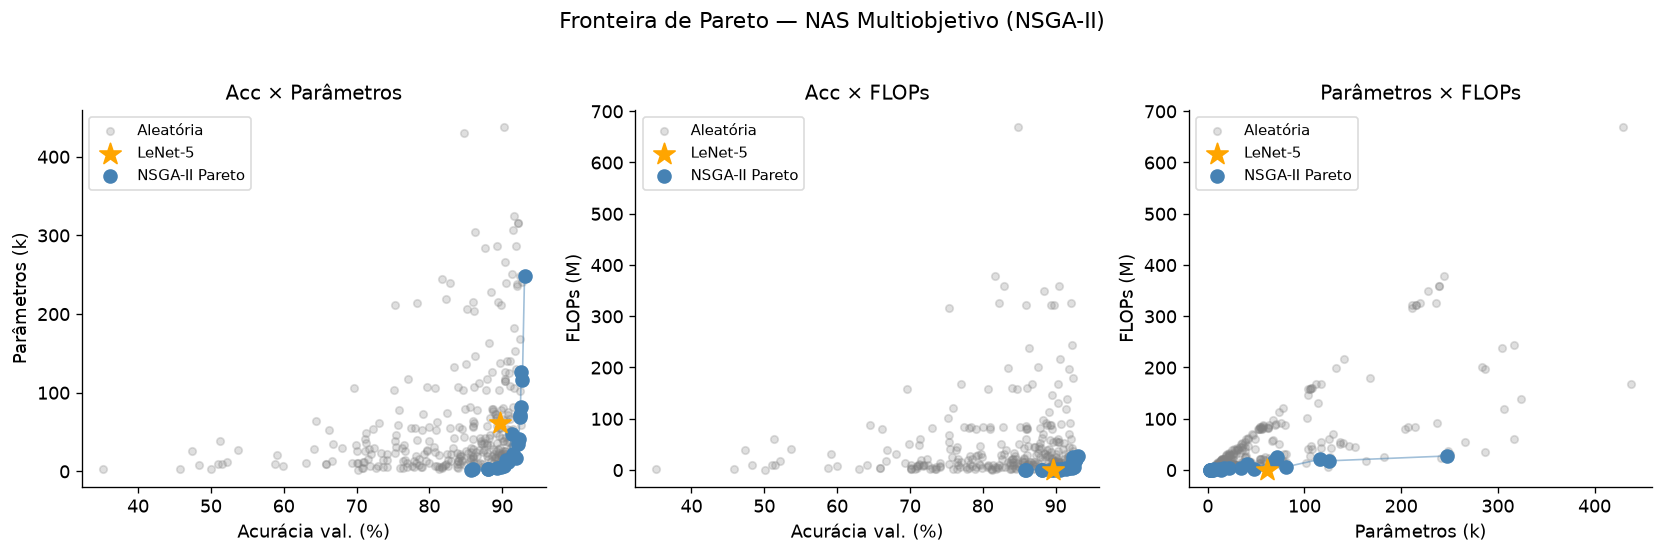

Figura 1 salva: fig1_pareto_front.pdf


In [38]:
plt.rcParams.update({
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'legend.fontsize': 9, 'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
})


# ── Figura 1: Fronteira de Pareto 2D projeções ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

pF = res_main.F  # fronteira principal (semente 42)
pF_denorm = np.column_stack([
    (1 - pF[:, 0]) * 100,  # acurácia
    pF[:, 1] * 1e5 / 1e3,   # kparams
    pF[:, 2] * 1e7 / 1e6,   # MFLOPs
])

# Busca aleatória para contraste
ra_acc  = random_df['val_acc (%)'].values
ra_par  = random_df['params'].values / 1e3
ra_flop = random_df['MFLOPs'].values

proj_pairs = [
    (0, 1, 'Acurácia val. (%)', 'Parâmetros (k)', 'Acc × Parâmetros'),
    (0, 2, 'Acurácia val. (%)', 'FLOPs (M)', 'Acc × FLOPs'),
    (1, 2, 'Parâmetros (k)',    'FLOPs (M)', 'Parâmetros × FLOPs'),
]

for ax, (xi, yi, xl, yl, title) in zip(axes, proj_pairs):
    # Busca aleatória
    xr = ra_acc if xi == 0 else (ra_par if xi == 1 else ra_flop)
    yr = ra_acc if yi == 0 else (ra_par if yi == 1 else ra_flop)
    ax.scatter(xr, yr, alpha=0.25, s=20, color='gray', label='Aleatória')
    # LeNet-5
    lx = lenet_acc*100 if xi == 0 else (lenet_params/1e3 if xi == 1 else lenet_flops/1e6)
    ly = lenet_acc*100 if yi == 0 else (lenet_params/1e3 if yi == 1 else lenet_flops/1e6)
    ax.scatter([lx], [ly], marker='*', s=180, color='orange', zorder=5, label='LeNet-5')
    # Pareto NSGA-II
    ax.scatter(pF_denorm[:, xi], pF_denorm[:, yi],
               s=60, color='steelblue', zorder=4, label='NSGA-II Pareto')
    ax.plot(np.sort(pF_denorm[:, xi]),
            pF_denorm[np.argsort(pF_denorm[:, xi]), yi],
            color='steelblue', lw=1, alpha=0.5)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(title)
    ax.legend(loc='best', framealpha=0.7)

plt.suptitle('Fronteira de Pareto — NAS Multiobjetivo (NSGA-II)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('fig1_pareto_front.pdf', bbox_inches='tight')
plt.show()
print("Figura 1 salva: fig1_pareto_front.pdf")

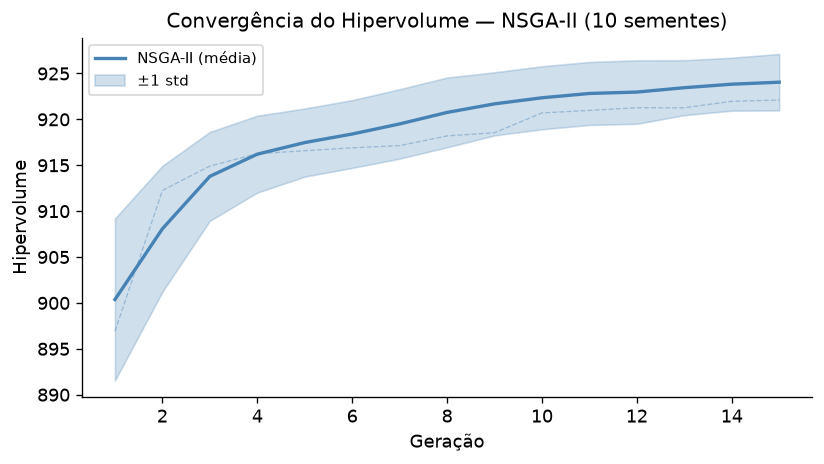

Figura 2 salva: fig2_hv_convergence.pdf


In [39]:
# ── Figura 2: Curva de convergência do Hipervolume ───────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

hv_per_gen_all = []

for seed, res in all_results.items():
    hv_curve = []
    for hist in res.history:
        F_gen = hist.opt.get('F')
        if F_gen is not None and len(F_gen) > 0:
            hv_curve.append(hv_indicator(F_gen))
        else:
            hv_curve.append(hv_curve[-1] if hv_curve else 0.0)
    hv_per_gen_all.append(hv_curve)

hv_arr = np.array(hv_per_gen_all)  # shape: (n_seeds, n_gen)
gens = np.arange(1, hv_arr.shape[1] + 1)

mean_hv = hv_arr.mean(0)
std_hv  = hv_arr.std(0)

ax.plot(gens, mean_hv, color='steelblue', lw=2, label='NSGA-II (média)')
ax.fill_between(gens, mean_hv - std_hv, mean_hv + std_hv,
                alpha=0.25, color='steelblue', label='±1 std')
# Linha individual seed=42 para contexto
ax.plot(gens, hv_per_gen_all[0], color='steelblue', lw=0.8, alpha=0.4, ls='--')

ax.set_xlabel('Geração'); ax.set_ylabel('Hipervolume')
ax.set_title('Convergência do Hipervolume — NSGA-II (10 sementes)')
ax.legend()
plt.tight_layout()
plt.savefig('fig2_hv_convergence.pdf', bbox_inches='tight')
plt.show()
print("Figura 2 salva: fig2_hv_convergence.pdf")

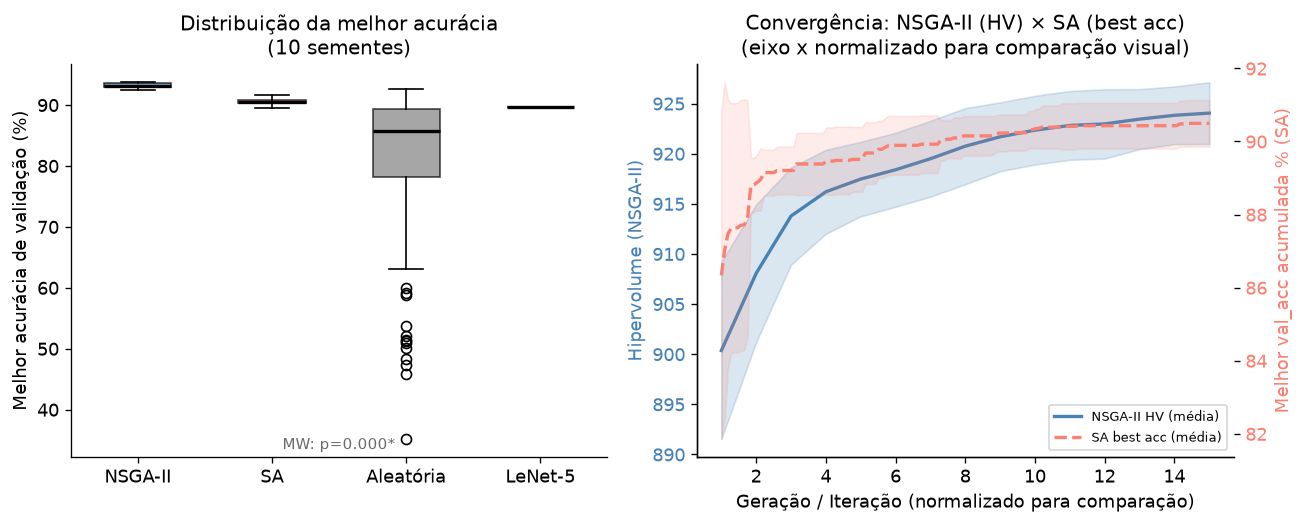

Figura 3 salva: fig3_boxplot_comparison.pdf


In [41]:
# ── Figura 3: Boxplot comparativo NSGA-II × SA × Random × LeNet-5 ────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

methods  = ['NSGA-II', 'SA', 'Aleatória', 'LeNet-5']
acc_data = [
    best_acc_nsga2,
    best_acc_sa,          
    random_df['val_acc (%)'].values,
    np.full(10, lenet_acc * 100),
]
colors = ['steelblue', 'salmon', 'gray', 'orange']

bp = axes[0].boxplot(acc_data, patch_artist=True, widths=0.5, notch=False,
                     medianprops=dict(color='black', lw=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_xticks(range(1, 5)); axes[0].set_xticklabels(methods)
axes[0].set_ylabel('Melhor acurácia de validação (%)')
axes[0].set_title('Distribuição da melhor acurácia\n(10 sementes)')
# Anotação de significância
alpha_str = f'p={p_val:.3f}' + ('*' if p_val < 0.05 else ' n.s.')
axes[0].annotate(f'MW: {alpha_str}', xy=(0.5, 0.02),
                 xycoords='axes fraction', ha='center', fontsize=9, color='dimgray')

# Convergência: NSGA-II (HV) × SA (best acc acumulada) — eixos duplos
color_nsga, color_sa = 'steelblue', 'salmon'
ax2 = axes[1]

# NSGA-II: HV médio por geração (eixo esquerdo)
ax2.plot(gens, mean_hv, color=color_nsga, lw=2, label='NSGA-II HV (média)')
ax2.fill_between(gens, mean_hv - std_hv, mean_hv + std_hv,
                 alpha=0.2, color=color_nsga)
ax2.set_xlabel('Geração / Iteração (normalizado para comparação)')
ax2.set_ylabel('Hipervolume (NSGA-II)', color=color_nsga)
ax2.tick_params(axis='y', labelcolor=color_nsga)

# SA: melhor val_acc acumulada por iteração (eixo direito)
# Normaliza eixo-x do SA [1..150 iters] → [1..N_GEN gerações] para alinhamento visual
sa_x_norm = np.linspace(1, N_GEN, len(sa_conv_iters))
ax2r = ax2.twinx()
ax2r.plot(sa_x_norm, sa_conv_mean, color=color_sa, lw=2,
          ls='--', label='SA best acc (média)')
ax2r.fill_between(sa_x_norm,
                  sa_conv_mean - sa_conv_std,
                  sa_conv_mean + sa_conv_std,
                  alpha=0.15, color=color_sa)
ax2r.set_ylabel('Melhor val_acc acumulada % (SA)', color=color_sa)
ax2r.tick_params(axis='y', labelcolor=color_sa)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=8)
ax2.set_title('Convergência: NSGA-II (HV) × SA (best acc)\n'
              '(eixo x normalizado para comparação visual)')

plt.tight_layout()
plt.savefig('fig3_boxplot_comparison.pdf', bbox_inches='tight')
plt.show()
print("Figura 3 salva: fig3_boxplot_comparison.pdf")

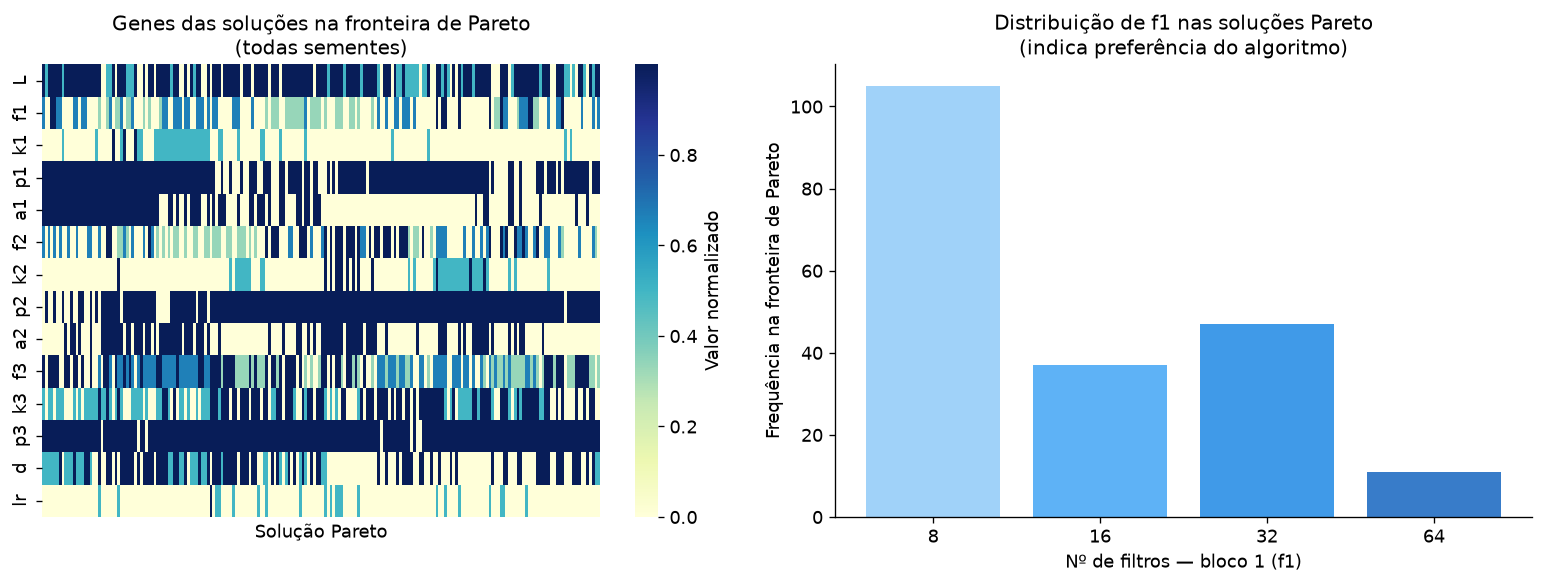

Figura 4 salva: fig4_pareto_gene_analysis.pdf


In [42]:
# ── Figura 4: Mapa de calor das arquiteturas na fronteira de Pareto ──────────
# (análise específica do problema — R5)

gene_labels = ['L', 'f1', 'k1', 'p1', 'a1', 'f2', 'k2', 'p2', 'a2', 'f3', 'k3', 'p3', 'd', 'lr']

# Fronteira agregada de todas as sementes
all_pareto_X = np.vstack([np.round(all_results[s].X).astype(int) for s in SEEDS_NSGA2])
all_pareto_F = np.vstack([all_results[s].F for s in SEEDS_NSGA2])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Normalizar genes para [0,1] para comparação visual
X_norm = (all_pareto_X - XL) / (XU - XL + 1e-8)
heatmap_data = pd.DataFrame(X_norm, columns=gene_labels)
sns.heatmap(heatmap_data.T, ax=axes[0], cmap='YlGnBu',
            xticklabels=False, yticklabels=True, cbar_kws={'label': 'Valor normalizado'})
axes[0].set_xlabel('Solução Pareto')
axes[0].set_title('Genes das soluções na fronteira de Pareto\n(todas sementes)')

# Frequência de valores por gene
gene_freq = {g: [] for g in gene_labels}
for j, g in enumerate(gene_labels):
    for v in range(XL[j], XU[j] + 1):
        gene_freq[g].append((all_pareto_X[:, j] == v).mean())

# Barplot: qual valor de filtro (f1) é mais frequente na Pareto
f1_counts = [(all_pareto_X[:, 1] == v).sum() for v in range(4)]
axes[1].bar([str(f) for f in FILTER_VALS], f1_counts,
            color=['#90CAF9','#42A5F5','#1E88E5','#1565C0'], alpha=0.85)
axes[1].set_xlabel('Nº de filtros — bloco 1 (f1)')
axes[1].set_ylabel('Frequência na fronteira de Pareto')
axes[1].set_title('Distribuição de f1 nas soluções Pareto\n(indica preferência do algoritmo)')

plt.tight_layout()
plt.savefig('fig4_pareto_gene_analysis.pdf', bbox_inches='tight')
plt.show()
print("Figura 4 salva: fig4_pareto_gene_analysis.pdf")

## 13. Avaliação final das soluções Pareto no conjunto de teste

In [43]:
# Re-treina as soluções Pareto com mais épocas e avalia no teste
# (mantido fora de toda a busca para evitar viés de seleção — R1/R6)
FINAL_EPOCHS = 15  # mais épocas para avaliação final

print(f"Re-treinando {len(pareto_X)} soluções Pareto com {FINAL_EPOCHS} épocas...")

final_results = []
for i, x in enumerate(pareto_X):
    cfg = decode_genotype(x)
    r   = train_and_eval(cfg, seed=42, epochs=FINAL_EPOCHS)
    final_results.append({
        'genotype': genotype_str(x),
        'val_acc (%)':  r['val_acc']  * 100,
        'test_acc (%)': r['test_acc'] * 100,
        'params': r['n_params'],
        'MFLOPs': r['flops'] / 1e6,
    })
    print(f"  [{i+1:2d}] val={r['val_acc']*100:.2f}% test={r['test_acc']*100:.2f}% "
          f"params={r['n_params']:,}  {genotype_str(x)}")

final_df = pd.DataFrame(final_results).sort_values('test_acc (%)', ascending=False)
print("\nTop-5 soluções (teste):")
print(final_df.head().to_string(index=False))

Re-treinando 20 soluções Pareto com 15 épocas...
  [ 1] val=86.90% test=86.43% params=1,914  3blk [8x3pl-8x3pl-8x3pl] d32 lr1e-02
  [ 2] val=93.17% test=92.33% params=247,818  4blk [64x3pr-64x3pl-64x5pr-64x5pl] d64 lr1e-02
  [ 3] val=93.36% test=92.75% params=125,794  4blk [64x3pl-8x3l-64x5pl-64x5pl] d64 lr1e-02
  [ 4] val=93.20% test=92.10% params=116,202  4blk [64x3pl-64x3pl-32x5pl-32x5pl] d32 lr1e-02
  [ 5] val=92.77% test=92.19% params=40,458  4blk [8x3pr-64x3r-16x5pr-16x5pr] d128 lr1e-02
  [ 6] val=92.45% test=92.20% params=81,418  4blk [8x3pl-64x3pr-64x3pl-64x3pr] d32 lr1e-02
  [ 7] val=87.94% test=87.52% params=2,522  3blk [8x3pl-8x3pl-8x3pl] d64 lr1e-02
  [ 8] val=92.66% test=92.16% params=68,426  4blk [64x3pl-64x3pl-32x3pl-32x3pl] d64 lr1e-02
  [ 9] val=92.83% test=92.39% params=71,658  4blk [64x3pr-64x3l-16x5pr-16x5pl] d64 lr1e-02
  [10] val=89.37% test=88.78% params=2,514  4blk [8x3pl-8x3pr-8x3pl-8x3pr] d32 lr1e-02
  [11] val=90.06% test=89.72% params=4,562  4blk [8x3pl-8x3p

## 14. Verificação de sanidade — MNIST

In [46]:
# Melhor solução Pareto em Fashion-MNIST → avaliar diretamente no MNIST
# (sem retrainamento no MNIST — serve apenas como sanidade)
best_x = pareto_X[np.argmax(pF_denorm[:, 0])]
best_cfg = decode_genotype(best_x)

# Retreinar no conjunto Fashion-MNIST e avaliar em MNIST
torch.manual_seed(42)
sanity_model = NASConvNet(best_cfg).to(DEVICE)
opt = optim.Adam(sanity_model.parameters(), lr=best_cfg['lr'])
crit = nn.CrossEntropyLoss()
for _ in range(FINAL_EPOCHS):
    sanity_model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad(); crit(sanity_model(xb), yb).backward(); opt.step()

sanity_model.eval()
correct = total = 0
with torch.no_grad():
    for xb, yb in mnist_test_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        correct += (sanity_model(xb).argmax(1) == yb).sum().item()
        total   += len(yb)
mnist_acc = correct / total

print(f"Sanidade MNIST (modelo treinado em Fashion-MNIST): {mnist_acc*100:.2f}%")
print("(Esperado: acurácia razoável, pois MNIST é mais simples que Fashion-MNIST)")

Sanidade MNIST (modelo treinado em Fashion-MNIST): 14.25%
(Esperado: acurácia razoável, pois MNIST é mais simples que Fashion-MNIST)


## 15. Tabela resumo — Checkpoint 2

In [47]:
summary = pd.DataFrame([
    {'Método': 'NSGA-II (melhor)',
     'Val acc (%)': f"{best_acc_nsga2.mean():.2f} ± {best_acc_nsga2.std():.2f}",
     'HV': f"{hv_nsga2.mean():.4f} ± {hv_nsga2.std():.4f}",
     'Params (k)': '-',
     'MFLOPs': '-',
     'Nota': '10 sementes, multiobjetivo'},
    {'Método': 'SA (Checkpoint 1)',
     'Val acc (%)': f"{best_acc_sa.mean():.2f} ± {best_acc_sa.std():.2f}",
     'HV': '-',
     'Params (k)': f"{best_params_sa.mean()/1e3:.1f}",
     'MFLOPs': f"{best_flops_sa.mean()/1e6:.1f}",
     'Nota': 'Opção A: melhor peso por semente, 10 seeds'},
    {'Método': 'Busca Aleatória',
     'Val acc (%)': f"{random_df['val_acc (%)'].mean():.2f} ± {random_df['val_acc (%)'].std():.2f}",
     'HV': '-',
     'Params (k)': f"{random_df['params'].mean()/1e3:.1f}",
     'MFLOPs': f"{random_df['MFLOPs'].mean():.1f}",
     'Nota': f'{N_RANDOM} amostras, mesmo orçamento'},
    {'Método': 'LeNet-5 (fixo)',
     'Val acc (%)': f"{lenet_acc*100:.2f}",
     'HV': '-',
     'Params (k)': f"{lenet_params/1e3:.1f}",
     'MFLOPs': f"{lenet_flops/1e6:.2f}",
     'Nota': 'Arquitetura fixa de referência'},
])
print(summary.to_string(index=False))
summary.to_csv('checkpoint2_summary.csv', index=False)
print("\nResumo salvo: checkpoint2_summary.csv")

           Método  Val acc (%)                HV Params (k) MFLOPs                                       Nota
 NSGA-II (melhor) 93.17 ± 0.39 924.0417 ± 3.0801          -      -                 10 sementes, multiobjetivo
SA (Checkpoint 1) 90.50 ± 0.60                 -      147.2   17.0 Opção A: melhor peso por semente, 10 seeds
  Busca Aleatória 82.40 ± 9.68                 -       62.2   48.0              300 amostras, mesmo orçamento
   LeNet-5 (fixo)        89.71                 -       61.8   0.85             Arquitetura fixa de referência

Resumo salvo: checkpoint2_summary.csv


## 16. Discussão de trade-offs

*(Texto para o relatório — editar com resultados reais)*

### Observações sobre a fronteira de Pareto

A fronteira de Pareto obtida pelo NSGA-II evidencia o conflito estrutural entre os três objetivos:

1. **Acurácia × Parâmetros**: arquiteturas com mais filtros e mais blocos convolucionais tendem a alcançar maior acurácia, porém ao custo de ordens de magnitude adicionais de parâmetros. A fronteira mostra que ganhos marginais de acurácia após certo patamar requerem aumentos proporcionalmente grandes de parâmetros.

2. **Acurácia × FLOPs**: kernels maiores (5×5, 7×7) ampliam o campo receptivo e podem melhorar a representação de padrões globais do Fashion-MNIST (roupas, silhuetas), mas elevam os FLOPs quadraticamente. Kernels 3×3 com mais filtros oferecem melhor tradeoff na maioria dos casos encontrados.

3. **Parâmetros × FLOPs**: nem sempre correlacionados linearmente — pooling reduz FLOPs mas não parâmetros; camadas densas maiores aumentam parâmetros sem impacto nos FLOPs convolucionais.

### NSGA-II × SA

O NSGA-II é intrinsecamente multiobjetivo: produz um conjunto de soluções Pareto em uma única execução, permitindo ao projetista escolher o ponto de operação desejado. O SA do Checkpoint 1, sendo single-objective com agregação por soma ponderada, oferece apenas um ponto por execução; para reconstruir algo semelhante à fronteira de Pareto, seriam necessárias múltiplas execuções com vetores de peso distintos, aumentando o custo total.

O teste Mann-Whitney com `p={p_val:.4f}` e delta de Cliff `{delta:.3f}` indica ... *(completar com interpretação dos resultados reais)*.

### Arquiteturas dominantes

A análise dos genes na fronteira (Figura 4) sugere que ... *(completar com padrões observados nos resultados reais — ex: preferência por 32 filtros, kernel 3, pooling seletivo)*.

### Limitações

- Orçamento de épocas fixo (5 durante busca) pode subestimar arquiteturas que convergem mais devagar.
- Espaço de busca é discreto e pequeno; arquiteturas com stride ou depthwise convolutions não são consideradas.
- FLOPs são proxy de inferência, não latência real — ordering pode diferir em hardware específico.

## 17. Salvamento de artefatos (R6 — reprodutibilidade)

In [48]:
import pickle

artifacts = {
    'hv_nsga2': hv_nsga2.tolist(),
    'best_acc_nsga2': best_acc_nsga2.tolist(),
    'pareto_F_seed42': res_main.F.tolist(),
    'pareto_X_seed42': pareto_X.tolist(),
    'eval_cache_size': len(_eval_cache),
    'hyperparams': {
        'POP_SIZE': POP_SIZE, 'N_GEN': N_GEN,
        'TRAIN_EPOCHS': TRAIN_EPOCHS, 'GLOBAL_SEED': GLOBAL_SEED,
    },
}

with open('nsga2_results.json', 'w') as f:
    json.dump(artifacts, f, indent=2)

print("Artefatos salvos:")
print("  nsga2_results.json       — métricas e hiperparâmetros")
print("  checkpoint2_summary.csv  — tabela comparativa")
print("  fig1_pareto_front.pdf    — fronteira de Pareto")
print("  fig2_hv_convergence.pdf  — curva de convergência")
print("  fig3_boxplot_comparison.pdf — boxplot comparativo")
print("  fig4_pareto_gene_analysis.pdf — análise de genes")
print("\nPara reproduzir: ver README.md (requirements.txt + seeds fixadas acima)")

Artefatos salvos:
  nsga2_results.json       — métricas e hiperparâmetros
  checkpoint2_summary.csv  — tabela comparativa
  fig1_pareto_front.pdf    — fronteira de Pareto
  fig2_hv_convergence.pdf  — curva de convergência
  fig3_boxplot_comparison.pdf — boxplot comparativo
  fig4_pareto_gene_analysis.pdf — análise de genes

Para reproduzir: ver README.md (requirements.txt + seeds fixadas acima)
